In [6]:
## load att maps for 3 koo lab models (HepG2, K562, WTC11 from koo_standardtorch)
import numpy as np
import pandas as pd
import h5py
from pathlib import Path

ATTR = Path('/grid/koo/home/pmantill/projects/kcee-ui/data/attributions')
LIB_CSV = ATTR / 'manifest.csv'
SRC_DIR = ATTR / 'koo_standardtorch'
CELLS = ['HepG2', 'K562', 'WTC11']

attr, pred = {}, {}
for ct in CELLS:
    with h5py.File(SRC_DIR / f'{ct}_intgrad.h5') as f:
        attr[ct] = f['attr'][:]
        pred[ct] = f['predictions'][:]
    print(f'{ct:6s} attr={attr[ct].shape} pred={pred[ct].shape}')

library = pd.read_csv(LIB_CSV)
print('library:', library.shape)

HepG2  attr=(56975, 4, 200) pred=(56975,)
K562   attr=(56975, 4, 200) pred=(56975,)
WTC11  attr=(56975, 4, 200) pred=(56975,)
library: (56975, 11)


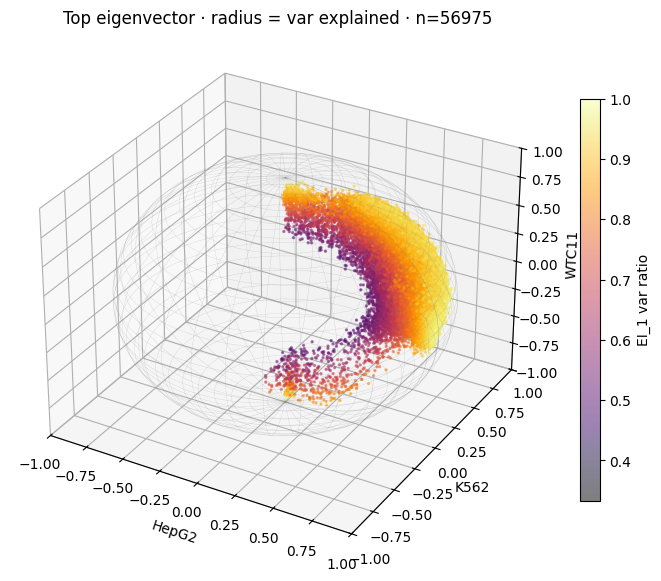

In [7]:
## plot the top Eigenvector per sample on the 3d unit sphere
import sys
sys.path.insert(0, '/grid/koo/home/pmantill/projects/kcee-ui')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from tangermeme.utils import one_hot_encode
from kcee_ui.scoring import attr_to_importance

A = {ct: attr[ct].astype(np.float32) for ct in CELLS}
N, _, L = A['HepG2'].shape

onehot = np.stack([
    one_hot_encode(s[15:15 + L]).numpy().astype(np.float32)
    for s in library['sequence'].to_numpy()
])

imp = np.stack([attr_to_importance(A[ct], onehot) for ct in CELLS], axis=-1)  # (N, L, 3)
C = np.einsum('nlk,nlj->nkj', imp.astype(np.float64), imp.astype(np.float64)) / L  # (N, 3, 3)

eigvals, eigvecs = np.linalg.eigh(C)            # ascending
vr1 = eigvals[:, -1] / eigvals.sum(1)
v1 = eigvecs[:, :, -1] * np.sign(eigvecs[:, :1, -1] + 1e-12)
v1_scaled = v1 * vr1[:, None]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
u, v = np.mgrid[0:2*np.pi:60j, 0:np.pi:30j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                  color='gray', lw=0.2, alpha=0.4)
sc = ax.scatter(v1_scaled[:, 0], v1_scaled[:, 1], v1_scaled[:, 2],
                c=vr1, cmap='inferno', s=2, alpha=0.5, vmin=1/3, vmax=1)
fig.colorbar(sc, ax=ax, shrink=0.6, label='EI_1 var ratio')
ax.set(xlabel=CELLS[0], ylabel=CELLS[1], zlabel=CELLS[2],
       xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       title=f'Top eigenvector · radius = var explained · n={N}')
plt.tight_layout()

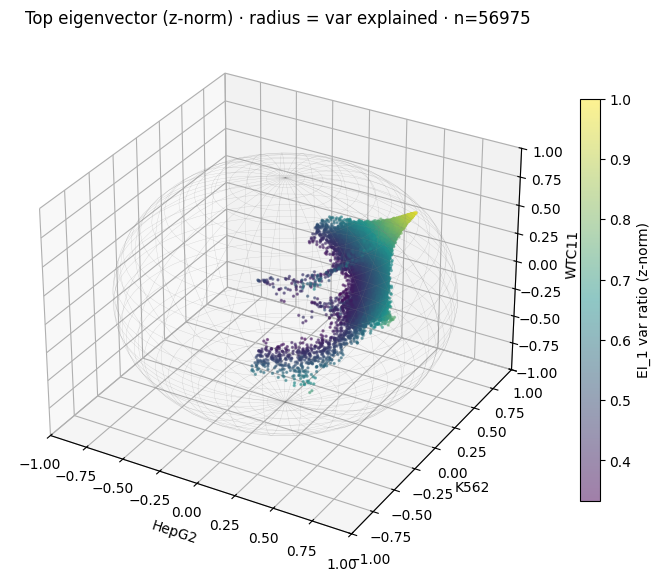

In [12]:
## z-norm variant: per-sample, per-CT mean-center + std-divide before 3x3 eigendecomp
from matplotlib.colors import LinearSegmentedColormap
tri_cmap = LinearSegmentedColormap.from_list('tri', ['#440154', '#21918c', '#fde725'])

E = imp.astype(np.float64)                              # (N, L, 3)
mu = E.mean(axis=1, keepdims=True)
sd = E.std(axis=1, keepdims=True)
E_z = (E - mu) / np.where(sd > 0, sd, 1.0)
C_z = np.einsum('nlk,nlj->nkj', E_z, E_z) / L           # (N, 3, 3)

eigvals_z, eigvecs_z = np.linalg.eigh(C_z)
vr1_z = eigvals_z[:, -1] / eigvals_z.sum(1)
v1_z = eigvecs_z[:, :, -1] * np.sign(eigvecs_z[:, :1, -1] + 1e-12)
v1_scaled_z = v1_z * vr1_z[:, None]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                  color='gray', lw=0.2, alpha=0.4)
sc = ax.scatter(v1_scaled_z[:, 0], v1_scaled_z[:, 1], v1_scaled_z[:, 2],
                c=vr1_z, cmap=tri_cmap, s=2, alpha=0.5, vmin=1/3, vmax=1)
fig.colorbar(sc, ax=ax, shrink=0.6, label='EI_1 var ratio (z-norm)')
ax.set(xlabel=CELLS[0], ylabel=CELLS[1], zlabel=CELLS[2],
       xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       title=f'Top eigenvector (z-norm) · radius = var explained · n={N}')
plt.tight_layout()

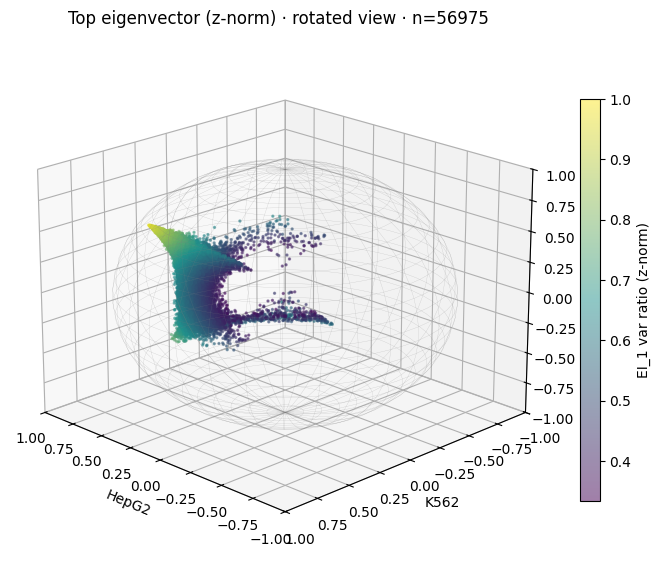

In [13]:
## same z-norm figure, rotated for a second viewing angle
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                  color='gray', lw=0.2, alpha=0.4)
sc = ax.scatter(v1_scaled_z[:, 0], v1_scaled_z[:, 1], v1_scaled_z[:, 2],
                c=vr1_z, cmap=tri_cmap, s=2, alpha=0.5, vmin=1/3, vmax=1)
fig.colorbar(sc, ax=ax, shrink=0.6, label='EI_1 var ratio (z-norm)')
ax.set(xlabel=CELLS[0], ylabel=CELLS[1], zlabel=CELLS[2],
       xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       title=f'Top eigenvector (z-norm) · rotated view · n={N}')
ax.view_init(elev=20, azim=135)
plt.tight_layout()

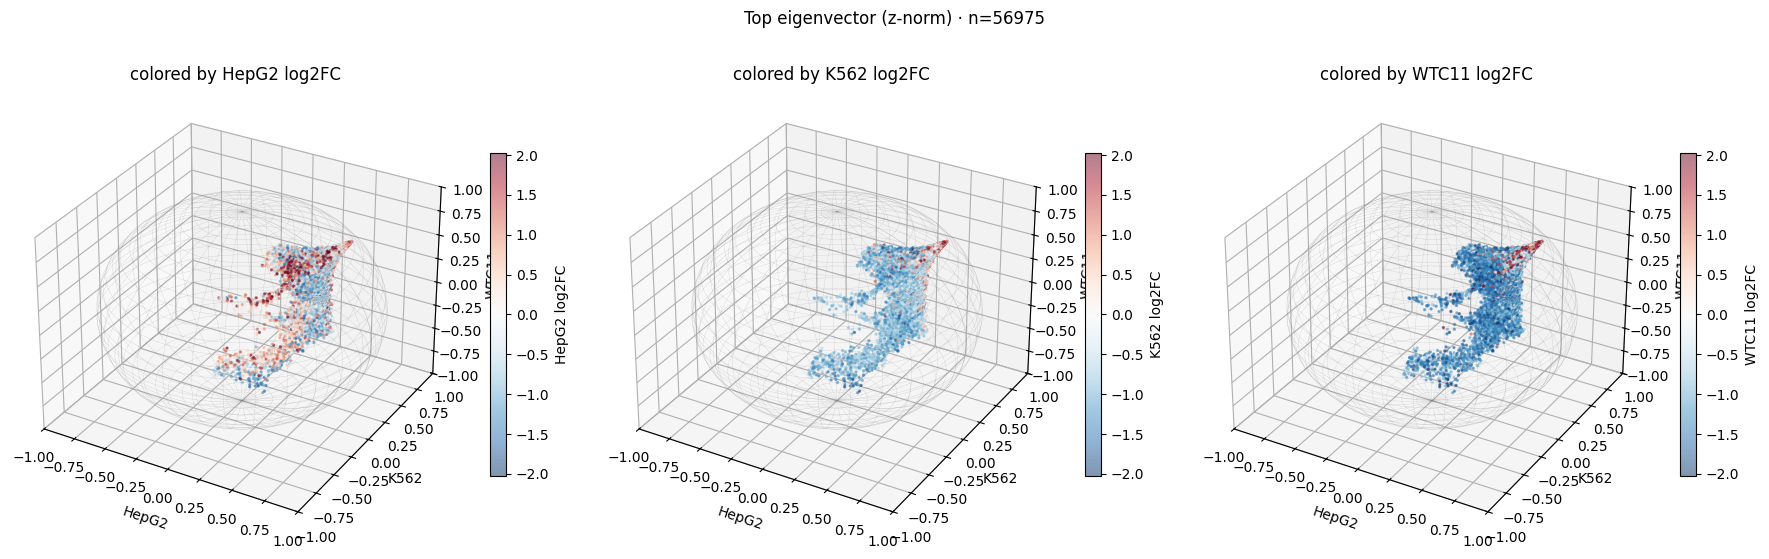

In [14]:
## same 3D unit sphere (first perspective), 3 panels — colored by per-CT log2FC activity
acts = library[[f'{ct}_log2FC' for ct in CELLS]].to_numpy(np.float32)  # (N, 3)
vmax_act = float(np.nanpercentile(np.abs(acts), 98))

fig = plt.figure(figsize=(18, 6))
for i, ct in enumerate(CELLS):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                      color='gray', lw=0.2, alpha=0.4)
    sc = ax.scatter(v1_scaled_z[:, 0], v1_scaled_z[:, 1], v1_scaled_z[:, 2],
                    c=acts[:, i], cmap='RdBu_r', s=2, alpha=0.5,
                    vmin=-vmax_act, vmax=vmax_act)
    fig.colorbar(sc, ax=ax, shrink=0.6, label=f'{ct} log2FC')
    ax.set(xlabel=CELLS[0], ylabel=CELLS[1], zlabel=CELLS[2],
           xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
           title=f'colored by {ct} log2FC')
fig.suptitle(f'Top eigenvector (z-norm) · n={N}')
plt.tight_layout()